## Biweekly 20.01

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats
from scipy.stats import chi2_contingency
from typing import Callable

def _resolve_project_root() -> Path:
    """locate project root containing config.py."""
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'config.py').exists():
            print(candidate)
            return candidate
    raise FileNotFoundError('config.py not found in cwd or parents')


PROJECT_ROOT = _resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# import config paths and helper functions
from config import (
    GENE_PATHS,
    SOURCE_PALETTE,
    VARIANT_PATHS,
    load_variants_processed,
    load_variant_pairs_matched,
)


/Users/markus/in-silico-vg-analysis


In [ ]:
# load gene-level summaries
gene_tables = {
    'clingen': pl.read_parquet(GENE_PATHS['clingen']),
    'background': pl.read_parquet(GENE_PATHS['background']),
    'background_null': pl.read_parquet(GENE_PATHS['background_null']),
    'clingen_null': pl.read_parquet(GENE_PATHS['clingen_null']),
}

for name, table in gene_tables.items():
    print(f'{name} gene shape: {table.shape}')

# load variant-level data using config functions
print('\nloading variant data...')

# load and deduplicate clingen variants (real + null with downsampling)
clingen_real, clingen_null = load_variant_pairs_matched(
    real_dataset='clingen',
    null_dataset='clingen_null',
    downsample=True,
    seed=42,
    verbose=True,
)

# load and deduplicate background variants (real + null with downsampling)
background_real, background_null = load_variant_pairs_matched(
    real_dataset='background',
    null_dataset='background_null',
    downsample=True,
    seed=42,
    verbose=True,
)

# combine into variant_tables dict for compatibility with downstream code
variant_tables = {
    'clingen': clingen_real,
    'background': background_real,
    'background_null': background_null,
    'clingen_null': clingen_null,
}

print('\nvariant table shapes:')
for name, table in variant_tables.items():
    print(f'  {name}: {table.shape}')


In [ ]:
# load AC (allele count) data from original TSV files
CLINGEN_TSV = Path(
    '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/'
    'dataset3_ClinGen/ClinGen_variants.tsv'
)
BG_TSV = Path(
    '/Users/markus/university/ML-in-biotech-CB206V-ws25/data/intermediate/'
    'dataset4_background/background_variants.tsv'
)


def _load_ac_table(path: str | Path, label: str) -> pl.DataFrame:
    """load ac from variant tsv.
    
    args:
        path (str | Path): tsv file path.
        label (str): dataset label for logging.
    
    returns:
        pl.DataFrame: variant_id, AC, gene_id.
    """
    file_path = Path(path)
    if not file_path.exists():
        raise FileNotFoundError(f'missing tsv for {label}: {file_path}')
    
    table = pl.read_csv(file_path, separator='\t')
    required = ['variant_id', 'AC', 'gene_tag']
    missing = [col for col in required if col not in table.columns]
    if missing:
        raise ValueError(f'missing columns in {file_path}: {missing}')
    
    # extract gene_id from gene_tag (format: ENSG00000123456|SYMBOL)
    table = (
        table
        .with_columns(
            pl.col('gene_tag').str.split('|').list.get(0).alias('gene_id')
        )
        .select(['variant_id', 'AC', 'gene_id'])
    )
    
    if table.is_empty():
        raise ValueError(f'no rows in tsv: {file_path}')
    
    return table


# load AC tables
ac_tables = {
    'clingen': _load_ac_table(path=CLINGEN_TSV, label='clingen'),
    'background': _load_ac_table(path=BG_TSV, label='background'),
}

# join AC values to real variant tables
matched_variants = {}
for name in ['clingen', 'background']:
    variants = variant_tables[name]
    
    if 'gene_id' not in variants.columns:
        raise ValueError(f'missing gene_id in {name} variants')
    
    ac_table = ac_tables[name].rename({'gene_id': 'gene_id_tsv', 'AC': 'ac'})
    joined = variants.join(ac_table, on='variant_id', how='left')
    
    missing_ac = joined.filter(pl.col('ac').is_null()).height
    coverage = 1 - (missing_ac / joined.height)
    print(f'{name} ac coverage: {coverage:.2%}')
    
    # drop the redundant gene_id_tsv column
    matched_variants[name] = joined.drop('gene_id_tsv')

print('\nmatched variant shapes (with AC):')
for name, table in matched_variants.items():
    print(f'  {name}: {table.shape}')


raw_p (perm median): {'AC=1': 0.04479104179164167, 'AC=2': 0.009198160367926415, 'AC=3': 0.005398920215956809, 'AC>4': 0.006998600279944011}
raw_p (perm mean): {'AC=1': 0.03999200159968006, 'AC=2': 0.04899020195960808, 'AC=3': 0.2393521295740852, 'AC>4': 0.013797240551889621}
raw_p (mann-whitney): {'AC=1': 0.013288870530871551, 'AC=2': 0.005393872695482869, 'AC=3': 0.016757598689035338, 'AC>4': 0.0040781928082978865}
raw p-values (original order):
label
AC=1   1.329e-02
AC=2   5.394e-03
AC=3   1.676e-02
AC>4   4.078e-03
Name: p_raw, dtype: float64

sorted p with qprime and monotone q:
       p_sorted  qprime_sorted  q_sorted_after_monotone
label                                                  
AC=1  1.329e-02      1.772e-02                1.676e-02
AC=2  5.394e-03      1.079e-02                1.079e-02
AC=3  1.676e-02      1.676e-02                1.676e-02
AC>4  4.078e-03      1.631e-02                1.079e-02

final q mapped back to labels:
label
AC=1   1.676e-02
AC=2   1.079e-02


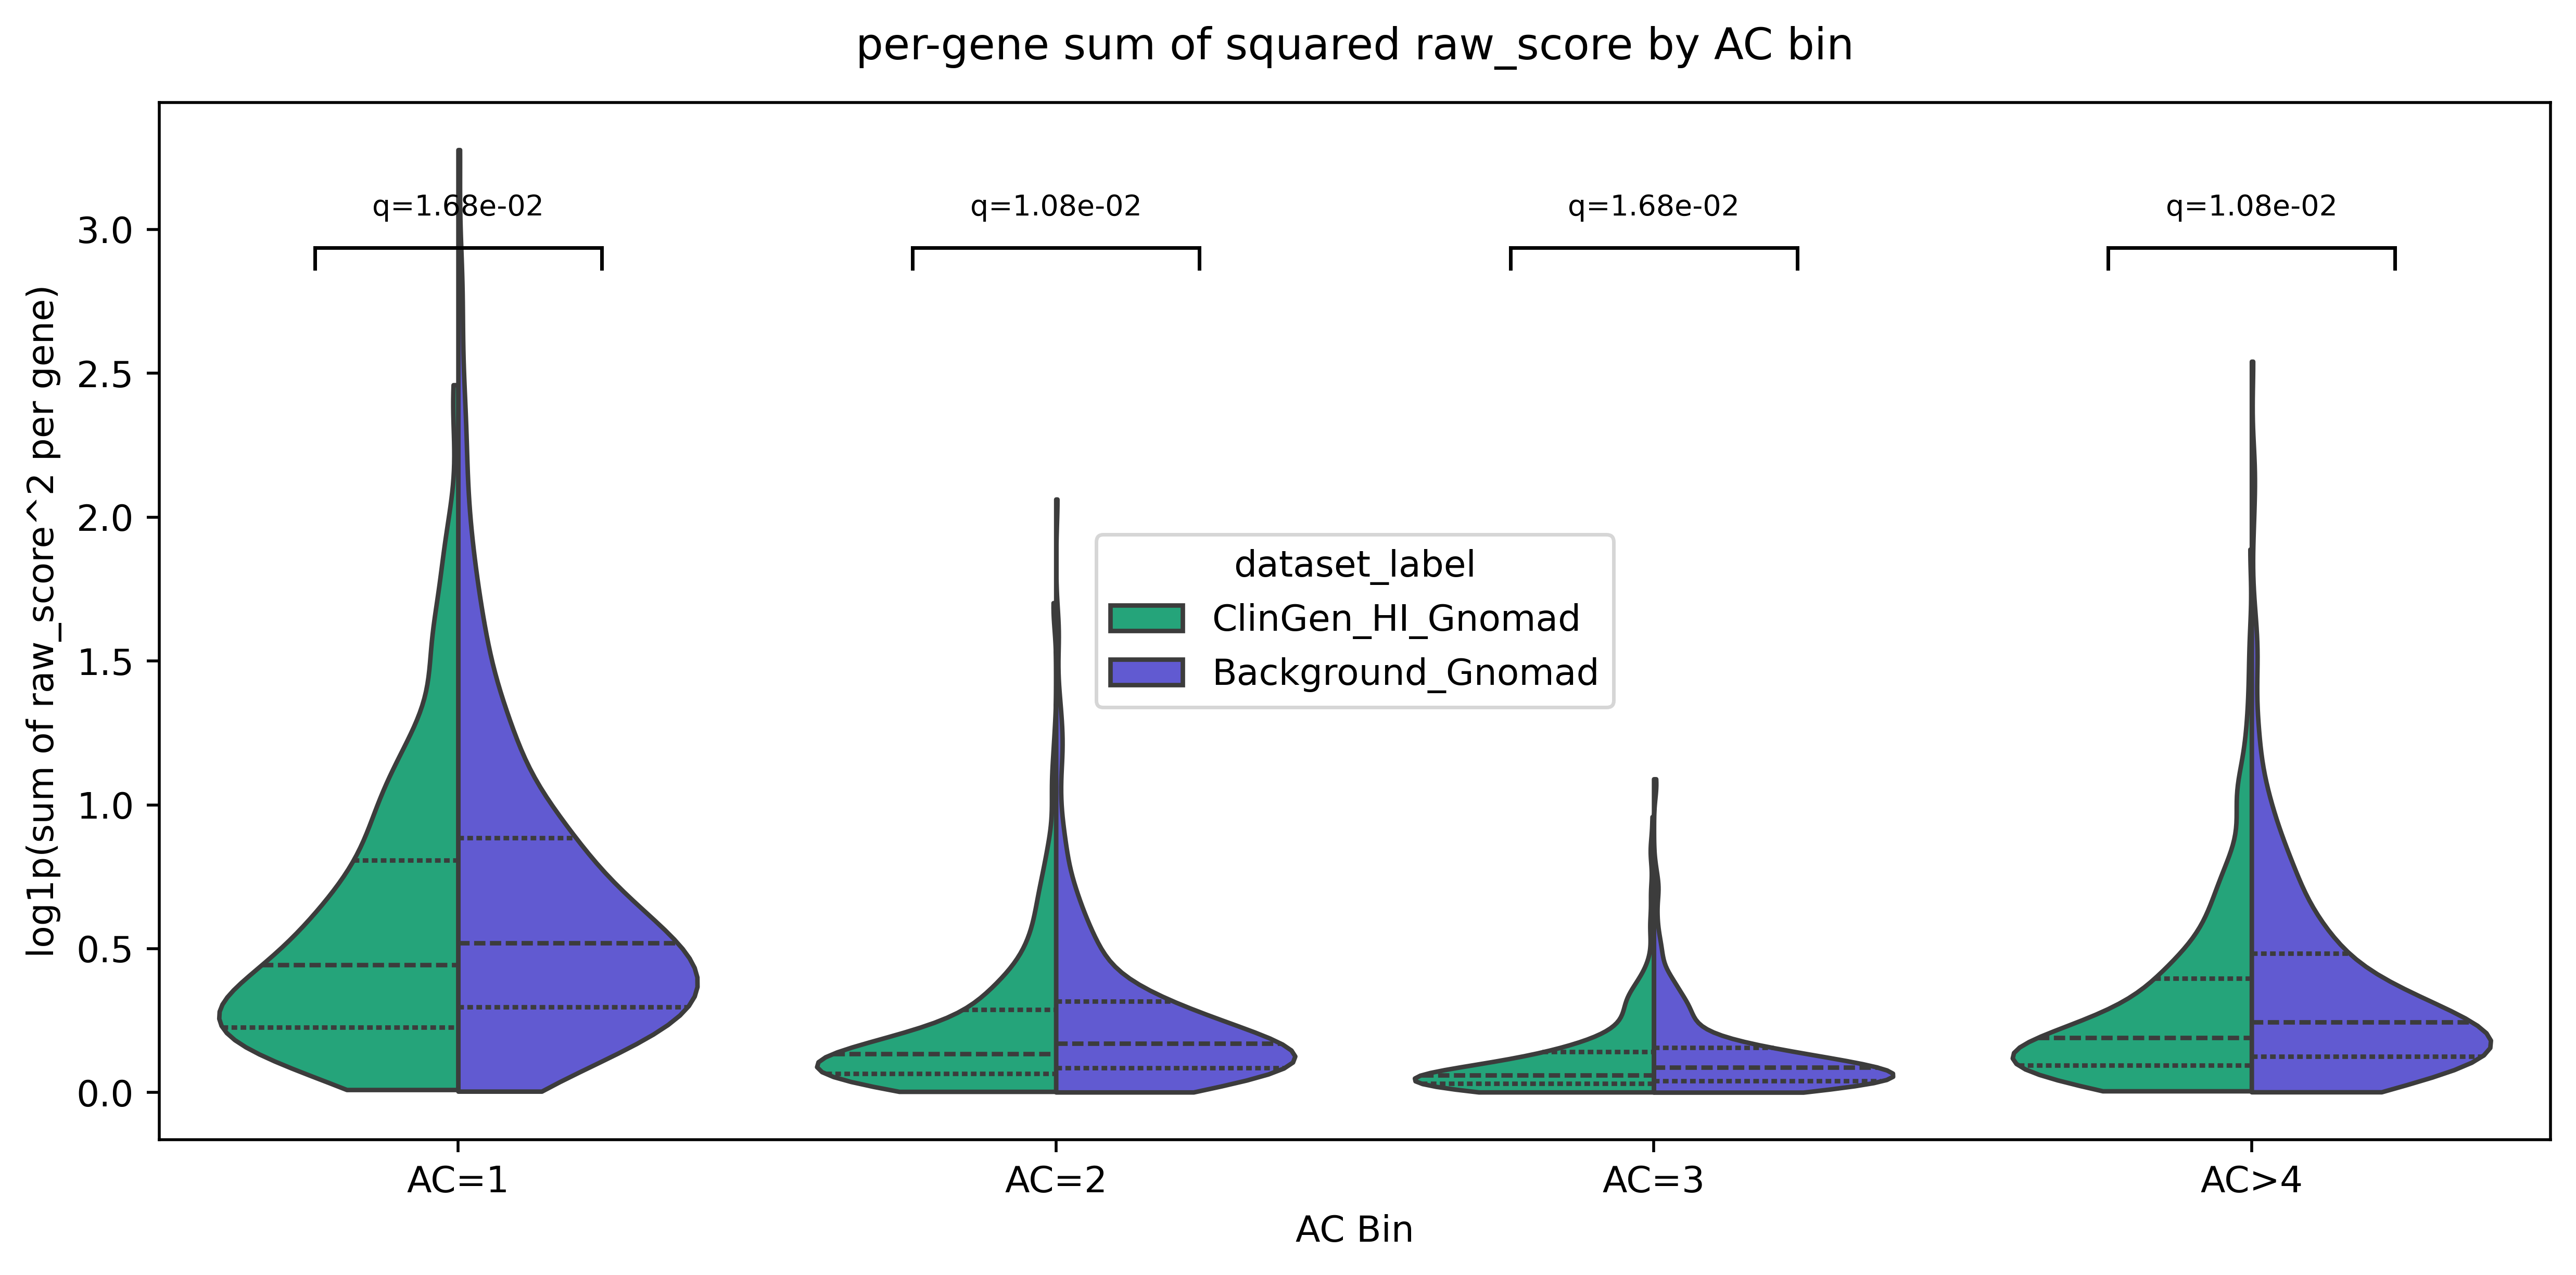

In [8]:
AC_BINS = {
    'AC=1': 1,
    'AC=2': 2,
    'AC=3': 3,
    'AC>4': 4,
}
AC_ORDER = list(AC_BINS.keys())


def _add_ac_bin(table: pl.DataFrame) -> pl.DataFrame:
    """assign ac bin labels for plotting.

    args:
        table (pl.DataFrame): variant table with ac.

    returns:
        pl.DataFrame: table with ac_bin column.
    """
    return table.with_columns(
        pl.when(pl.col('ac') == 1)
        .then(pl.lit('AC=1'))
        .when(pl.col('ac') == 2)
        .then(pl.lit('AC=2'))
        .when(pl.col('ac') == 3)
        .then(pl.lit('AC=3'))
        .when(pl.col('ac') > 4)
        .then(pl.lit('AC>4'))
        .otherwise(None)
        .alias('ac_bin')
    )


def _sum_sq_by_gene_ac(table: pl.DataFrame) -> pl.DataFrame:
    """aggregate sum of squared raw_score per gene and ac bin.

    args:
        table (pl.DataFrame): variant table with gene_id, raw_score, ac.

    returns:
        pl.DataFrame: per-gene aggregates by ac bin.
    """
    return (
        _add_ac_bin(table)
        .filter(pl.col('ac_bin').is_not_null())
        .group_by(['gene_id', 'ac_bin'])
        .agg(pl.col('raw_score').pow(2).sum().alias('sum_sq_raw_score'))
    )


def _fdr_bh(p_values: dict[str, float]) -> dict[str, float]:
    labels = [k for k, p in p_values.items() if not np.isnan(p)]
    p = np.array([p_values[k] for k in labels], dtype=float)
    m = p.size
    if m == 0:
        return dict(p_values)

    # sort p ascending
    order = np.argsort(p)
    p_sorted = p[order]

    # BH adjust on sorted p's
    q_sorted = p_sorted * m / (np.arange(1, m + 1))

    # enforce monotonicity (non-decreasing q with increasing p)
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_sorted = np.clip(q_sorted, 0.0, 1.0)

    # map back to original label order
    q = np.empty_like(q_sorted)
    q[order] = q_sorted

    out = dict(p_values)
    for k, val in zip(labels, q.tolist(), strict=True):
        out[k] = float(val)
    return out


def _permutation_test_median(
    a: np.ndarray,
    b: np.ndarray,
    n_perm: int = 5000,
    seed: int = 0,
) -> float:
    """estimate two-sided permutation p-value on median difference.

    args:
        a (np.ndarray): first sample.
        b (np.ndarray): second sample.
        n_perm (int): number of permutations.
        seed (int): random seed.

    returns:
        float: permutation p-value.
    """
    rng = np.random.default_rng(seed)
    pooled = np.concatenate([a, b])
    n_a = a.size
    obs = np.abs(np.median(a) - np.median(b))
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        if np.abs(np.median(perm[:n_a]) - np.median(perm[n_a:])) >= obs:
            count += 1
    return (count + 1) / (n_perm + 1)


def _permutation_test_mean(
    a: np.ndarray,
    b: np.ndarray,
    n_perm: int = 5000,
    seed: int = 0,
) -> float:
    """estimate two-sided permutation p-value on mean difference.

    args:
        a (np.ndarray): first sample.
        b (np.ndarray): second sample.
        n_perm (int): number of permutations.
        seed (int): random seed.

    returns:
        float: permutation p-value.
    """
    rng = np.random.default_rng(seed)
    pooled = np.concatenate([a, b])
    n_a = a.size
    obs = np.abs(np.mean(a) - np.mean(b))
    count = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        if np.abs(np.mean(perm[:n_a]) - np.mean(perm[n_a:])) >= obs:
            count += 1
    return (count + 1) / (n_perm + 1)


def _compute_raw_p_values(length_long: pd.DataFrame) -> dict[str, float]:
    """compute permutation p-values on median per ac bin.

    args:
        length_long (pd.DataFrame): long-form table with dataset and ac_bin.

    returns:
        dict[str, float]: raw p-values keyed by ac_bin label.
    """
    p_values: dict[str, float] = {}
    for ac_bin in AC_ORDER:
        subset = length_long[length_long['ac_bin'] == ac_bin]
        clingen_vals = subset.loc[
            subset['dataset'] == 'clingen', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        background_vals = subset.loc[
            subset['dataset'] == 'background', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        if clingen_vals.size == 0 or background_vals.size == 0:
            p_values[ac_bin] = float('nan')
            continue
        p_values[ac_bin] = _permutation_test_median(clingen_vals, background_vals)
    return p_values


def _compute_raw_p_values_mean(length_long: pd.DataFrame) -> dict[str, float]:
    """compute permutation p-values on mean per ac bin.

    args:
        length_long (pd.DataFrame): long-form table with dataset and ac_bin.

    returns:
        dict[str, float]: raw p-values keyed by ac_bin label.
    """
    p_values: dict[str, float] = {}
    for ac_bin in AC_ORDER:
        subset = length_long[length_long['ac_bin'] == ac_bin]
        clingen_vals = subset.loc[
            subset['dataset'] == 'clingen', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        background_vals = subset.loc[
            subset['dataset'] == 'background', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        if clingen_vals.size == 0 or background_vals.size == 0:
            p_values[ac_bin] = float('nan')
            continue
        p_values[ac_bin] = _permutation_test_mean(clingen_vals, background_vals)
    return p_values


def _compute_raw_p_values_mwu(length_long: pd.DataFrame) -> dict[str, float]:
    """compute mann-whitney p-values per ac bin.

    args:
        length_long (pd.DataFrame): long-form table with dataset and ac_bin.

    returns:
        dict[str, float]: raw p-values keyed by ac_bin label.
    """
    p_values: dict[str, float] = {}
    for ac_bin in AC_ORDER:
        subset = length_long[length_long['ac_bin'] == ac_bin]
        clingen_vals = subset.loc[
            subset['dataset'] == 'clingen', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        background_vals = subset.loc[
            subset['dataset'] == 'background', 'sum_sq_raw_score_log1p'
        ].to_numpy()
        if clingen_vals.size == 0 or background_vals.size == 0:
            p_values[ac_bin] = float('nan')
            continue
        _, p_value = stats.mannwhitneyu(clingen_vals, background_vals, alternative='two-sided')
        p_values[ac_bin] = float(p_value)
    return p_values


def _bh_debug_print(raw_p: dict[str, float]) -> None:
    """print bh intermediate values for debugging.

    args:
        raw_p (dict[str, float]): raw p-values keyed by label.

    returns:
        None
    """
    labels = [label for label, value in raw_p.items() if not np.isnan(value)]
    p_arr = np.array([raw_p[label] for label in labels], dtype=float)
    if p_arr.size == 0:
        print('no valid p-values')
        return

    order = np.argsort(p_arr)
    p_sorted = p_arr[order]
    qprime = p_sorted * p_arr.size / (np.arange(1, p_arr.size + 1))
    qprime_clip = np.clip(qprime, 0.0, 1.0)
    q_sorted = np.minimum.accumulate(qprime_clip[::-1])[::-1]

    q_mapped = np.empty_like(q_sorted)
    q_mapped[order] = q_sorted

    df = pd.DataFrame({'label': labels, 'p_raw': p_arr}).set_index('label')
    df['p_sorted'] = pd.Series(p_sorted, index=[labels[i] for i in order])
    df['qprime_sorted'] = pd.Series(qprime_clip, index=[labels[i] for i in order])
    df['q_sorted_after_monotone'] = pd.Series(q_sorted, index=[labels[i] for i in order])
    df['q_final_mapped'] = pd.Series(q_mapped, index=labels)

    pd.set_option('display.float_format', '{:.3e}'.format)
    print('raw p-values (original order):')
    print(df['p_raw'])
    print('\nsorted p with qprime and monotone q:')
    print(df[['p_sorted', 'qprime_sorted', 'q_sorted_after_monotone']].dropna())
    print('\nfinal q mapped back to labels:')
    print(df['q_final_mapped'])


def _rank_biserial(a: np.ndarray, b: np.ndarray) -> float:
    """compute rank-biserial effect size from mann-whitney u.

    args:
        a (np.ndarray): first sample.
        b (np.ndarray): second sample.

    returns:
        float: rank-biserial effect size.
    """
    u_stat, _ = stats.mannwhitneyu(a, b, alternative='two-sided')
    n_a = a.size
    n_b = b.size
    if n_a == 0 or n_b == 0:
        return float('nan')
    return 1 - (2.0 * u_stat) / (n_a * n_b)


frames: list[pl.DataFrame] = []
for dataset in ['clingen', 'background']:
    table = matched_variants[dataset]
    missing = [col for col in ['gene_id', 'raw_score', 'ac'] if col not in table.columns]
    if missing:
        raise ValueError(f'missing columns in {dataset} table: {missing}')
    agg = _sum_sq_by_gene_ac(table).with_columns(pl.lit(dataset).alias('dataset'))
    frames.append(agg)

sum_sq_long = pl.concat(frames, how='vertical').to_pandas()
sum_sq_long['sum_sq_raw_score_log1p'] = np.log1p(sum_sq_long['sum_sq_raw_score'])

DATASET_LABELS = {
    'clingen': 'ClinGen_HI_Gnomad',
    'background': 'Background_Gnomad',
}
DATASET_PALETTE = {
    DATASET_LABELS['clingen']: SOURCE_PALETTE['clingen'],
    DATASET_LABELS['background']: SOURCE_PALETTE['background'],
}

sum_sq_long['dataset_label'] = sum_sq_long['dataset'].map(DATASET_LABELS)

plt.figure(figsize=(10, 5), dpi=500)
ax = sns.violinplot(
    data=sum_sq_long,
    x='ac_bin',
    y='sum_sq_raw_score_log1p',
    hue='dataset_label',
    order=AC_ORDER,
    palette=DATASET_PALETTE,
    cut=0,
    density_norm='width',
    split=True,
    inner='quartile',
)

from matplotlib.lines import Line2D


def _add_bracket_annotation(
    ax: plt.Axes,
    x_center: float,
    y: float,
    text: str,
    width: float,
    lineheight: float,
) -> None:
    """draw bracket with text centered at the given x coordinate.

    args:
        ax (plt.Axes): axis to draw on.
        x_center (float): x location for the bracket.
        y (float): y location for the bracket.
        text (str): annotation text.
        width (float): bracket width in axis units.
        lineheight (float): bracket tick height.

    returns:
        None
    """
    left = x_center - (width / 2)
    right = x_center + (width / 2)
    ax.add_line(Line2D([left, right], [y, y], color='black', linewidth=1.0, clip_on=True))
    ax.add_line(
        Line2D([left, left], [y, y - lineheight], color='black', linewidth=1.0, clip_on=True)
    )
    ax.add_line(
        Line2D([right, right], [y, y - lineheight], color='black', linewidth=1.0, clip_on=True)
    )
    ax.text(x_center, y + (lineheight * 1.2), text, ha='center', va='bottom', fontsize=8)


raw_p = _compute_raw_p_values(sum_sq_long)
raw_p_mean = _compute_raw_p_values_mean(sum_sq_long)
raw_p_mwu = _compute_raw_p_values_mwu(sum_sq_long)
q_values = _fdr_bh(raw_p_mwu)

# debug bh inputs
print('raw_p (perm median):', raw_p)
print('raw_p (perm mean):', raw_p_mean)
print('raw_p (mann-whitney):', raw_p_mwu)
_bh_debug_print(raw_p_mwu)

# effect size
rank_biserial = {}
for ac_bin in AC_ORDER:
    subset = sum_sq_long[sum_sq_long['ac_bin'] == ac_bin]
    clingen_vals = subset.loc[
        subset['dataset'] == 'clingen', 'sum_sq_raw_score_log1p'
    ].to_numpy()
    background_vals = subset.loc[
        subset['dataset'] == 'background', 'sum_sq_raw_score_log1p'
    ].to_numpy()
    rank_biserial[ac_bin] = _rank_biserial(clingen_vals, background_vals)

print('rank-biserial (log1p):', rank_biserial)

n_bins = len(AC_ORDER)
x_centers_axes = [(idx + 0.5) / n_bins for idx in range(n_bins)]
y_bracket_ax = 0.86
y_text_ax = 0.885
width_ax = 0.12
tick_ax = 0.02

for idx, ac_bin in enumerate(AC_ORDER):
    left_ax = x_centers_axes[idx] - (width_ax / 2)
    right_ax = x_centers_axes[idx] + (width_ax / 2)

    ax.add_line(
        Line2D(
            [left_ax, right_ax],
            [y_bracket_ax, y_bracket_ax],
            transform=ax.transAxes,
            color='black',
            linewidth=1.0,
            clip_on=True,
        )
    )
    ax.add_line(
        Line2D(
            [left_ax, left_ax],
            [y_bracket_ax, y_bracket_ax - tick_ax],
            transform=ax.transAxes,
            color='black',
            linewidth=1.0,
            clip_on=True,
        )
    )
    ax.add_line(
        Line2D(
            [right_ax, right_ax],
            [y_bracket_ax, y_bracket_ax - tick_ax],
            transform=ax.transAxes,
            color='black',
            linewidth=1.0,
            clip_on=True,
        )
    )

    q_value = q_values[ac_bin]
    if np.isnan(q_value):
        label = 'q=n/a'
    else:
        label = f'q={q_value:.2e}'

    ax.text(
        x_centers_axes[idx],
        y_text_ax,
        label,
        ha='center',
        va='bottom',
        fontsize=8,
        transform=ax.transAxes,
        clip_on=True,
    )

ax.set_xlabel('AC Bin')
ax.set_ylabel('log1p(sum of raw_score^2 per gene)')
ax.set_title('per-gene sum of squared raw_score by AC bin', pad=12)
#ax.legend(title='dataset', loc='upper right')
plt.tight_layout()


# What's new this week

1. We will change the naming for NULL sets to synthetic (SYNTH) and specify that our ClinGen dataset is Haploinsufficent. Therefore the new naming from here on will be. The reason to do this is because NULL is too vauge description for our usecase. 

- ClinGen_HI_Gnomad 
- ClinGen_HI_Synth
- Background_Gnomad
- Background_Sytnh

2. We will introduce VG scores to our Synthetic datasets. We do this by  comparing observed per-gene genetic variance to a permutation-based null distribution generated by randomly reassigning allele frequencies (AFs) from a global pool of observed variants keeping the distingtion between ClinGen_HI and Background datasets. Our new variants file have now new column vg_predicted_perm

3. For our gene level analysis we divide genes by different categories based on if the gene is singleton or doubleton or tripleton. We make extra annotations to our vairant level files on from AC values from intermediate variant files and calculate with aggregator module fractions of how many variants are affecting the gene level absolute score.

4. We calculate the gene-metrics correlations between whole groups, not just feature based